In [1]:
#Jonathan Borowsky
#6/20/25
#Grabe lab

In [2]:
import numpy as np
import time
from decimal import Decimal
import matplotlib.pyplot as plt

import westpa
from westpa.analysis import Run
import pyemma

import westpa_h5_reader_msm_functions as hmf
import weighted_msms

In [3]:
#used as an adapter between my MSM construction and pyemma's
class msm():
    def __init__(self, eqp, sio):
        self.stationary_distribution = eqp
        self.active_set = sio

loaded data for 2000 WE rounds in 169.28249096870422 seconds
identified 239848 transitions in 0.010605573654174805 seconds


pyemma.msm.estimators.bayesian_msm.BayesianMSM[14]: Sampling MSMs:   0%|                                      …

built MSM in 37.84577751159668 seconds
loaded data for 1000 WE rounds in 87.07660126686096 seconds
identified 122572 transitions in 0.006015300750732422 seconds


pyemma.msm.estimators.bayesian_msm.BayesianMSM[15]: Sampling MSMs:   0%|                                      …

built MSM in 18.04401445388794 seconds
loaded data for 2000 WE rounds in 82.39242625236511 seconds
identified 115084 transitions in 0.0061109066009521484 seconds


pyemma.msm.estimators.bayesian_msm.BayesianMSM[16]: Sampling MSMs:   0%|                                      …

built MSM in 15.989355564117432 seconds
loaded data for 2000 WE rounds in 153.2135293483734 seconds
identified 216064 transitions in 0.009873628616333008 seconds


pyemma.msm.estimators.bayesian_msm.BayesianMSM[17]: Sampling MSMs:   0%|                                      …

built MSM in 33.52971076965332 seconds


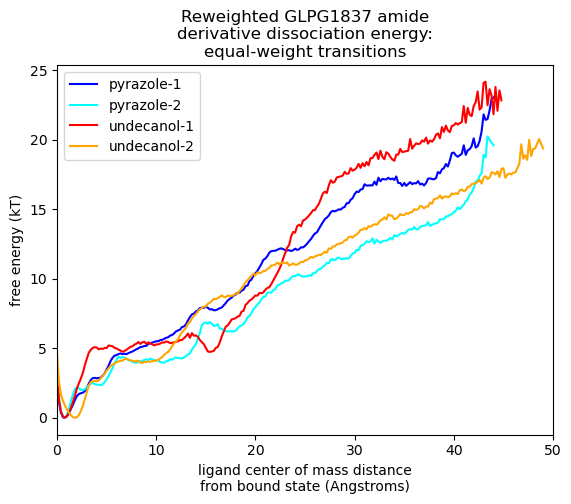

In [9]:

#whether to construct MSMs using pyemma or using my MLE method. Only the latter supports weighting
use_pyemma=True
#whether to construct the MSM transition counts matrix using the WE weight of the walker making each transition.
#if False every walker has a weight of 1
weighted=False

#whether to use the same evenly-spaced bins for all MSMs or make the MSM bin boundaries match Chloe's WE bin boundaries
uniform_bins = True

#output file name
if weighted:
    plottitle = "Reweighted GLPG1837 amide\nderivative dissociation energy:\nWE-weighted transitions"
    savefigname = "glpg_reweighted_dissociation_energy_WE_weighted_transitions"
else:
    plottitle = "Reweighted GLPG1837 amide\nderivative dissociation energy:\nequal-weight transitions"
    savefigname = "glpg_reweighted_dissociation_energy_unweighted_transitions"

#input files and parameters
cftr_west = "/home/jonathan/Documents/grabelab/cftr/chloe-data"
cftr_refpc = "/home/jonathan/Documents/grabelab/cftr/refeaturization"

h5paths_names = [ [f"{cftr_west}/wstp_cftr_1_degrabo/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_1", "pyrazole-1",  "blue",   0, 2001, [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 25.5, 26, 26.5, 27,28,29,30,32,34,36,38, 40, 50]],
                  [f"{cftr_west}/wstp_cftr_2_wynton/west-040925.h5",  f"{cftr_refpc}/nonlip_glpg_2", "pyrazole-2",  "cyan",   0, 1001, [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 25.5, 26, 26.5, 27,28,29,30,32,34,36,38, 40, 50]],
                  [f"{cftr_west}/wstp_lip_glpg_1/west-040925.h5",     f"{cftr_refpc}/lip_glpg_1",    "undecanol-1", "red",    0, 2001, [0, 1, 3, 5, 7, 9, 10, 11, 12, 15, 16, 17, 18, 19, 19.5, 20, 20.5, 21, 21.5, 22, 22.5, 23, 24, 25, 25.5, 26, 26.5, 27,28,29,30,32,34,36,38, 40, 50]],
                  [f"{cftr_west}/wstp_lip_glpg_2/west-040925.h5",     f"{cftr_refpc}/lip_glpg_2",    "undecanol-2", "orange", 0, 2001, [0,1,1.3,1.5,1.7,2,2.2,2.4,2.5,2.75,3,3.25,3.5,3.75,4,4.25,4.5,4.75,5,5.25,5.5,5.75,6,6.5,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,25.5,26,26.5,27,28,29,30,32,34,36,38,40,41,50]]
]

uniform_we_bins = np.arange(0,50,0.2)

legend=[]

for h5pn in h5paths_names:
    h5path = h5pn[0]

    #binning along continuous PC
    if uniform_bins:
        binbounds = uniform_we_bins
    else:
        binbounds = h5pn[4]
        
    pclims = [binbounds[0], binbounds[-1]]
    nb = len(binbounds)+1
    
    #discrete PC; this is essentially irrelevant since the PC for this project is 1D
    n_discrete_pc_vals = 1
    
    #load data
    t1 = time.time()
    pcs, parent_pcs, weights, pc_init, maxiter = hmf.h5_2_pcs(h5path, h5pn[4], h5pn[5])
    t2 = time.time()
    print(f"loaded data for {len(pcs)} WE rounds in {t2-t1} seconds")

    for rmax in [h5pn[5]]: #range(200,maxiter,200): #loop can be used to assess convergence (data are not converged)

        #get transitions
        t3 = time.time()
        transitions = hmf.pcs_2_transitions(np.concatenate(pcs[:rmax]), np.concatenate(parent_pcs[:rmax]), binbounds, n_discrete_pc_vals)
        t4 = time.time()
        print(f"identified {len(transitions)} transitions in {t4-t3} seconds")
    
        #build MSMs
        t5 = time.time()
        
        if use_pyemma:
            #consider using deeptime instead, or https://moldyn.github.io/msmhelper/ which is supposedly faster
            pyem = pyemma.msm.bayesian_markov_model(list(transitions), lag=1, reversible=True)
            #plt.plot([-np.log(p) for p in pyem.stationary_distribution])
            
        elif weighted:
            tpm, sio = weighted_msms.transitions_2_msm(transitions, np.concatenate(weights[:rmax]))
            eqp = weighted_msms.tpm_2_eqprobs(tpm)
            pyem = msm(eqp.transpose()[0], sio)
        else:
            tpm, sio = weighted_msms.transitions_2_msm(transitions, np.ones(transitions.shape[0]))
            eqp = weighted_msms.tpm_2_eqprobs(tpm)
            pyem = msm(eqp.transpose()[0], sio)
        
        t6 = time.time()
        print(f"built MSM in {t6-t5} seconds")
        
        # get plot data correcting for ergodic trimming
        bin_x_all, energies = hmf.plot_2d_pc_webins(pyem, nb, binbounds, pclims, n_discrete_pc_vals, plottitle=savefigname, zeromin=True)
    
        plt.plot(bin_x_all[0], energies[0], color=h5pn[3])
        legend.append(h5pn[2])
    
    #plt.show()
    
plt.legend(legend)
plt.title(plottitle)
plt.xlim(0, 50)

plt.xlabel("ligand center of mass distance\nfrom bound state (Angstroms)")
plt.ylabel("free energy (kT)")

plt.savefig(savefigname+".svg", dpi=600, format="svg", bbox_inches="tight")
